In [76]:
# Calculating the lookback time
# SIbusiso Mathebula
# 31/08/2026

In [77]:
import numpy as np
import matplotlib.pyplot as plt


In [78]:
# Define cosmological parameters
h= 0.7
omega_m_0= 0.3
omega_r_0= 1e-4
omega_lambda_0= 1 - omega_m_0 - omega_r_0



In [79]:
def Hubble_parameter(z):
    """Calculate the Hubble parameter at redshift z."""
    return h * 100 * np.sqrt(omega_m_0 * (1 + z)**3 + omega_r_0 * (1 + z)**4 + omega_lambda_0)

In [80]:
def trapezoidal_intergration(z,N=10000):
    z_vals = np.linspace(0, z, N+1)
    h = z / N
    
    integral = (h/2) * (
            f(z_vals[0]) +
            2*np.sum(f(z_vals[1:N])) +
            f(z_vals[N])
        )
    
    return  integral

In [81]:
def f(z):
    """Function to integrate for lookback time."""
    return 1 / ((1 + z) * Hubble_parameter(z))

In [82]:
z_values = np.linspace(0, 1100, 10000)
z_values_log = np.log(z_values+1)
lookback_times = [1000*trapezoidal_intergration(z) for z in z_values]


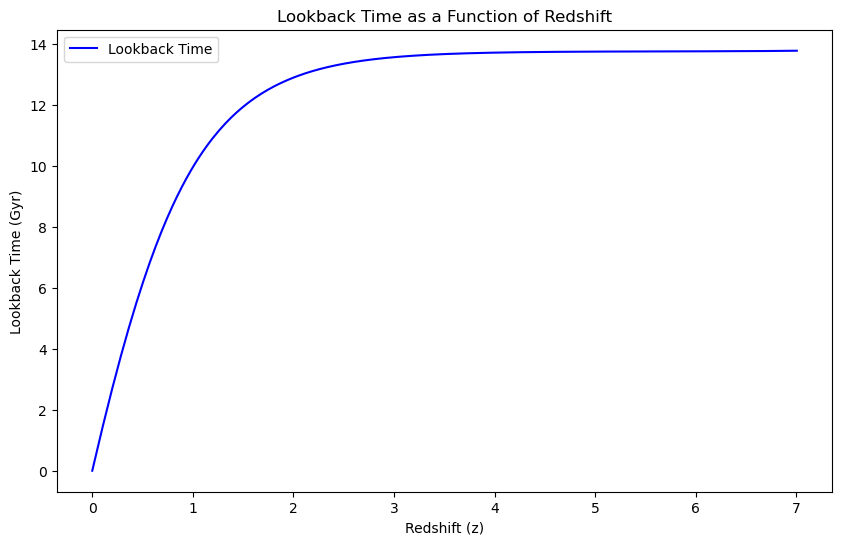

In [83]:
#plot the lookback time as a function of redshift
plt.figure(figsize=(10, 6))
plt.plot(z_values_log, lookback_times, label='Lookback Time', color='blue')
plt.title('Lookback Time as a Function of Redshift')
plt.xlabel('Redshift (z)')
plt.ylabel('Lookback Time (Gyr)')



plt.legend()

In [85]:
# Lookback time at z=1
lookback_time = 1000*trapezoidal_intergration(1)
print(f"Lookback time at z=1: {lookback_time:.2f} Gyr")
lookback_time_decoupling = 1000*trapezoidal_intergration(1090)
print(f"Lookback time at decoupling (z=1090): {lookback_time_decoupling:.2f} Gyr")


Lookback time at z=1: 7.89 Gyr
Lookback time at decoupling (z=1090): 13.79 Gyr
